In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/customer_features.csv
/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/cohort_retention_matrix.csv
/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/olist_master_clean.csv


# Monte Carlo Revenue Forecasting

## Objective

Previous notebooks focused on understanding historical marketplace performance and experimentation outcomes.

This notebook uses Monte Carlo Simulation to forecast future revenue outcomes and quantify uncertainty.

Business Questions:

- What revenue should Olist expect next month?
- What is the probability of exceeding revenue targets?
- What are the best-case and worst-case scenarios?
- How much uncertainty exists in revenue forecasting?

# 1. Imports

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
master = pd.read_csv("/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/olist_master_clean.csv")

master.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,on_time_delivery,delivery_speed_group,negative_handoff_flag,customer_order_number,first_purchase_date,days_since_first_purchase,repeat_customer_flag,cohort_month,order_month_period,cohort_index
0,e22acc9c116caa3f2b7121bbb380d08e,1,372645c7439f9661fbbacfd129aa92ec,da8622b14eb17ae2831f4ac5b9dab84a,2018-05-15 11:11:18,129.90,12.00,fadbb3709178fc513abc1b2670aa1ad2,delivered,2018-05-10 10:56:27,...,True,fast,0,1,2018-05-10 10:56:27,0,0,2018-05,2018-05,1
1,3594e05a005ac4d06a72673270ef9ec9,1,5099f7000472b634fea8304448d20825,138dbe45fc62f1e244378131a6801526,2018-05-11 17:56:33,18.90,8.29,4cb282e167ae9234755102258dd52ee8,delivered,2018-05-07 11:11:27,...,True,fast,0,1,2018-05-07 11:11:27,0,0,2018-05,2018-05,1
2,b33ec3b699337181488304f362a6b734,1,64b488de448a5324c4134ea39c28a34b,3d871de0142ce09b7081e2b9d1733cb1,2017-03-15 21:05:03,69.00,17.22,9b3932a6253894a02c1df9d19004239f,delivered,2017-03-10 21:05:03,...,True,slow,0,1,2017-03-10 21:05:03,0,0,2017-03,2017-03,1
3,41272756ecddd9a9ed0180413cc22fb6,1,2345a354a6f2033609bbf62bf5be9ef6,ef506c96320abeedfb894c34db06f478,2017-10-18 21:49:17,25.99,17.63,914991f0c02ef0843c0e7010c819d642,delivered,2017-10-12 20:29:41,...,True,slow,0,1,2017-10-12 20:29:41,0,0,2017-10,2017-10,1
4,d957021f1127559cd947b62533f484f7,1,c72e18b3fe2739b8d24ebf3102450f37,70a12e78e608ac31179aea7f8422044b,2017-11-22 20:06:52,180.00,16.89,47227568b10f5f58a524a75507e6992c,delivered,2017-11-14 19:45:42,...,True,slow,0,1,2017-11-14 19:45:42,0,0,2017-11,2017-11,1


In [6]:
master.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'delivery_date_missing_flag',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'product_category_name_english',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'review_score',
 'review_creation_date',
 'review_answer_timestamp',
 'total_payment_value',
 'payment_installments_max',
 'payment_type_primary',
 'approval_latency_days',
 'carrier_handoff_days',
 'carrier_transit_days',
 'delivery_days',
 'delivery_promise_gap_days',
 'on_time_delivery',
 'delivery_speed_group',
 'negative_handoff_flag',
 'customer_order_number',
 'first_purchase_date',
 'days_si

# 2. Build Monthly Revenue Dataset

In [8]:
master["order_purchase_timestamp"] = pd.to_datetime(master["order_purchase_timestamp"])

master["order_month"] = (master["order_purchase_timestamp"].dt.to_period("M").astype(str))

In [9]:
monthly_revenue = ( master.groupby("order_month")
    .agg(revenue=("total_payment_value","sum"),
        orders=("order_id","nunique"),
        customers=("customer_unique_id","nunique")
    ) .reset_index()
)

monthly_revenue

,order_month,revenue,orders,customers
0,2016-09,347.52,3,3
1,2016-10,73914.58,308,305
2,2016-12,19.62,1,1
3,2017-01,187779.41,789,755
4,2017-02,344134.79,1733,1708
5,2017-03,526961.66,2641,2601
6,2017-04,505665.53,2391,2359
7,2017-05,724504.55,3660,3588
8,2017-06,600753.27,3217,3154
9,2017-07,737293.08,3969,3894


In [10]:
print(monthly_revenue.shape)

monthly_revenue.describe()

(24, 4)


,revenue,orders,customers
count,2.400000e+01,24.000000,24.000000
mean,8.461723e+05,4111.083333,4054.958333
std,5.424075e+05,2615.223208,2586.244759
min,1.962000e+01,1.000000,1.000000
25%,4.652828e+05,2226.500000,2196.250000
50%,9.429777e+05,4268.000000,4190.500000
75%,1.317463e+06,6512.500000,6442.500000
max,1.583869e+06,7451.000000,7342.000000


## Why Monthly Aggregation?

Monte Carlo simulation operates on monthly business outcomes rather than individual transactions.

Aggregating revenue at the monthly level allows us to model:

- Revenue variability
- Seasonal fluctuations
- Business risk
- Future performance scenarios

The historical monthly revenue distribution serves as the foundation for all subsequent simulations.

# 3. Historical Revenue Trend

Before forecasting future revenue, it is important to understand historical revenue behavior.

This analysis helps identify:

- Growth patterns
- Revenue volatility
- Seasonal effects
- Potential outlier months

These observations provide context for interpreting simulation results later in the notebook.

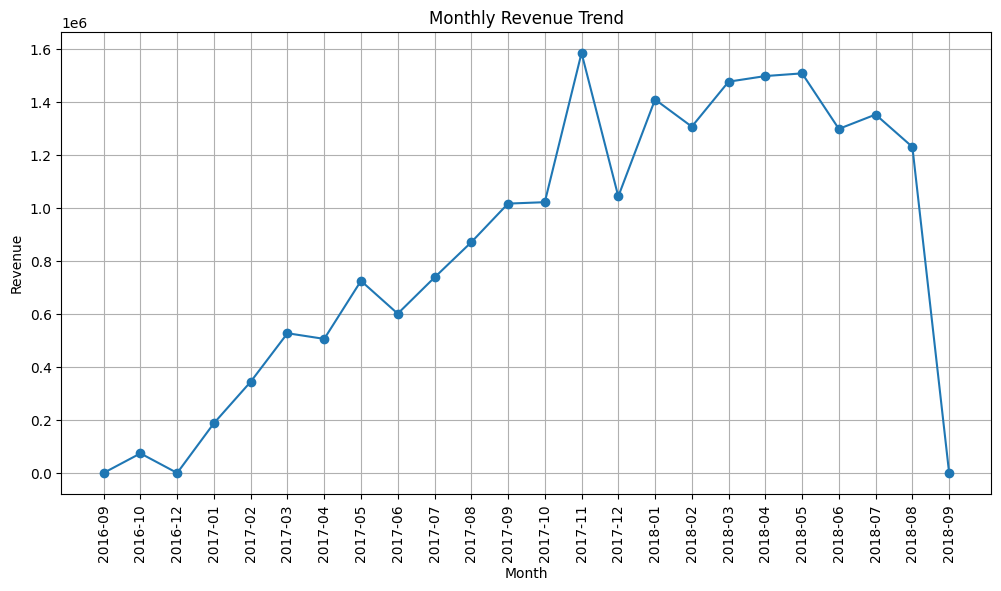

In [24]:
plt.figure(figsize=(12,6))

plt.plot(monthly_revenue["order_month"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.xticks(rotation=90)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

# 4. Remove Partial Months

The first and last months in the dataset contain partial transaction records.

These months are removed to prevent forecast bias and ensure simulations are based on representative marketplace activity.

In [13]:
monthly_revenue_clean = monthly_revenue[~monthly_revenue["order_month"].isin(
        ["2016-09","2016-12","2018-09"])].copy()

print(monthly_revenue_clean.shape)

monthly_revenue_clean

(21, 4)


,order_month,revenue,orders,customers
1,2016-10,73914.58,308,305
3,2017-01,187779.41,789,755
4,2017-02,344134.79,1733,1708
5,2017-03,526961.66,2641,2601
6,2017-04,505665.53,2391,2359
7,2017-05,724504.55,3660,3588
8,2017-06,600753.27,3217,3154
9,2017-07,737293.08,3969,3894
10,2017-08,870105.90,4293,4211
11,2017-09,1015849.57,4243,4170


# 5. Historical Revenue Distribution

Monte Carlo simulation assumes future outcomes are related to historical outcomes.

Understanding the distribution of historical monthly revenue helps quantify uncertainty and risk.

In [14]:
monthly_revenue_clean["revenue"].describe()

count    2.100000e+01
mean     9.670286e+05
std      4.643751e+05
min      7.391458e+04
25%      6.007533e+05
50%      1.021169e+06
75%      1.351705e+06
max      1.583869e+06
Name: revenue, dtype: float64

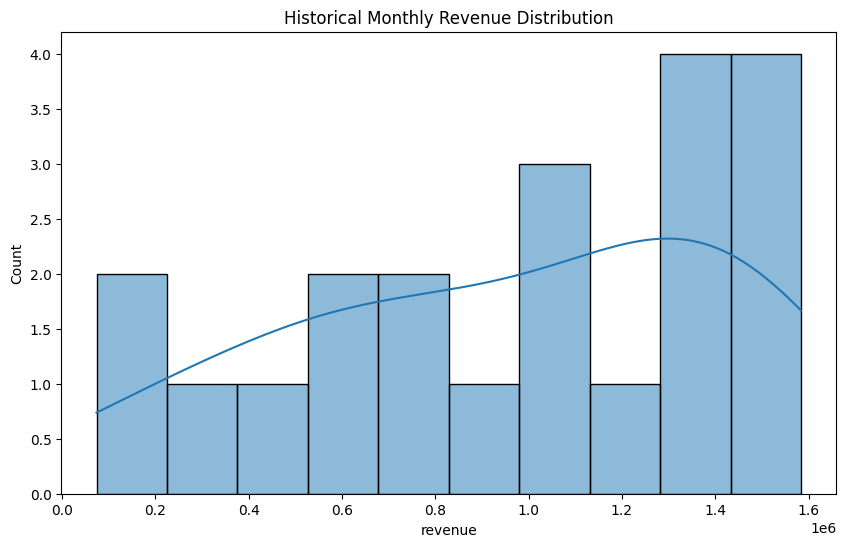

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(monthly_revenue_clean["revenue"],bins=10,kde=True)

plt.title("Historical Monthly Revenue Distribution")

plt.show()

# 6. Monte Carlo Simulation

Monte Carlo simulation generates thousands of possible future revenue outcomes using historical revenue patterns.

Rather than predicting a single revenue value, the simulation produces a probability distribution of potential outcomes.

This allows business leaders to assess:

- Expected performance
- Revenue uncertainty
- Downside risk
- Upside potential

In [16]:
historical_revenue = (monthly_revenue_clean["revenue"].values)

n_simulations = 10000

simulated_revenue = np.random.choice(
    historical_revenue,
    size=n_simulations,
    replace=True)

# 7. Forecast Distribution

The simulated revenue distribution represents thousands of possible future business scenarios generated from historical performance.

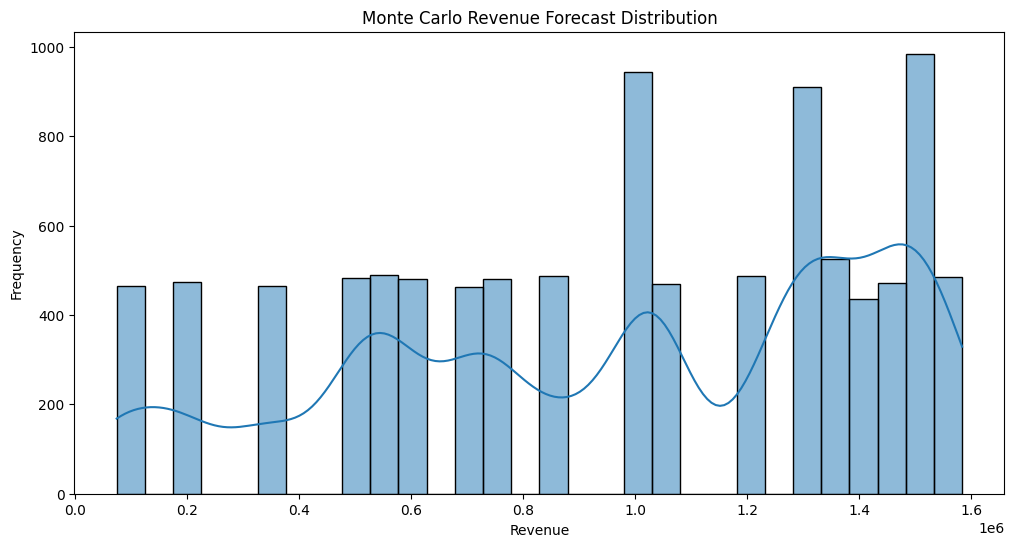

In [17]:
plt.figure(figsize=(12,6))

sns.histplot(simulated_revenue,
    bins=30,
    kde=True
)

plt.title("Monte Carlo Revenue Forecast Distribution")

plt.xlabel("Revenue")

plt.ylabel("Frequency")

plt.show()

# 8. Expected Revenue

The average of all simulated outcomes represents the expected future monthly revenue.

In [18]:
expected_revenue = simulated_revenue.mean()

print(f"Expected Revenue: {expected_revenue:,.2f}")

Expected Revenue: 969,061.80


# 9. Forecast Interval

Forecast intervals provide a realistic range of expected future revenue outcomes.

The 5th and 95th percentiles represent a 90% forecast interval.

In [19]:
lower = np.percentile(simulated_revenue,5)

upper = np.percentile(simulated_revenue,95)

print(f"90% Forecast Interval: ({lower:,.0f}, {upper:,.0f})")

90% Forecast Interval: (187,779, 1,506,975)


# 10. Revenue Target Analysis

Management often evaluates business performance relative to revenue goals.

This section estimates the probability of achieving a predefined revenue target.

In [20]:
target = 1400000

prob_target = np.mean(simulated_revenue >= target)

print( f"Probability Revenue >= {target:,.0f}: {prob_target:.2%}")

Probability Revenue >= 1,400,000: 23.79%


# 11. Scenario Analysis

Percentile-based scenario analysis provides insight into potential downside and upside business outcomes.

In [21]:
worst_case = np.percentile(simulated_revenue,1)

best_case = np.percentile( simulated_revenue, 99)

print(f"Worst Case Revenue (1%): {worst_case:,.0f}")

print(f"Best Case Revenue (99%): {best_case:,.0f}")

Worst Case Revenue (1%): 73,915
Best Case Revenue (99%): 1,583,869


# 12. Revenue Risk Assessment

Revenue risk is measured as the probability that future revenue falls below a critical business threshold.

In [23]:
risk_below_1m = np.mean(simulated_revenue < 1000000)

print(f"Probability Revenue < 1M: {risk_below_1m:.2%}")

Probability Revenue < 1M: 42.85%


# 13. Limitations of the Initial Monte Carlo Model

The initial Monte Carlo simulation sampled directly from historical monthly revenue values.

While useful for illustrating uncertainty and scenario analysis, this approach assumes that every historical month is equally likely to occur in the future.

This assumption may not be realistic because:

- Revenue exhibits a clear growth trend over time.
- Early marketplace months had substantially lower revenue than recent months.
- The business scale in 2018 differs significantly from the business scale in 2016.

As a result, the simulation may underestimate future revenue by assigning equal probability to historical low-revenue months.

To address this limitation, a second forecasting approach will model monthly growth rates rather than raw revenue values.

# 14. Historical Growth Rate Analysis

Instead of forecasting revenue directly, we analyze historical month-over-month growth rates.

Growth rates capture how revenue changes through time and allow forecasts to preserve the current business scale.

This approach is often more realistic for growing businesses because future revenue is estimated by applying historical growth behavior to the most recent revenue level.# 14. Historical Growth Rate Analysis

Instead of forecasting revenue directly, we analyze historical month-over-month growth rates.

Growth rates capture how revenue changes through time and allow forecasts to preserve the current business scale.

This approach is often more realistic for growing businesses because future revenue is estimated by applying historical growth behavior to the most recent revenue level.

In [25]:
monthly_revenue_clean["growth_rate"] = (monthly_revenue_clean["revenue"].pct_change())

monthly_revenue_clean[["order_month","revenue","growth_rate"]].head()

,order_month,revenue,growth_rate
1,2016-10,73914.58,NaN
3,2017-01,187779.41,1.540492
4,2017-02,344134.79,0.832655
5,2017-03,526961.66,0.531265
6,2017-04,505665.53,-0.040413


In [26]:
monthly_revenue_clean["growth_rate"].describe()

count    20.000000
mean      0.207843
std       0.423626
min      -0.341577
25%      -0.048472
50%       0.085760
75%       0.371061
max       1.540492
Name: growth_rate, dtype: float64

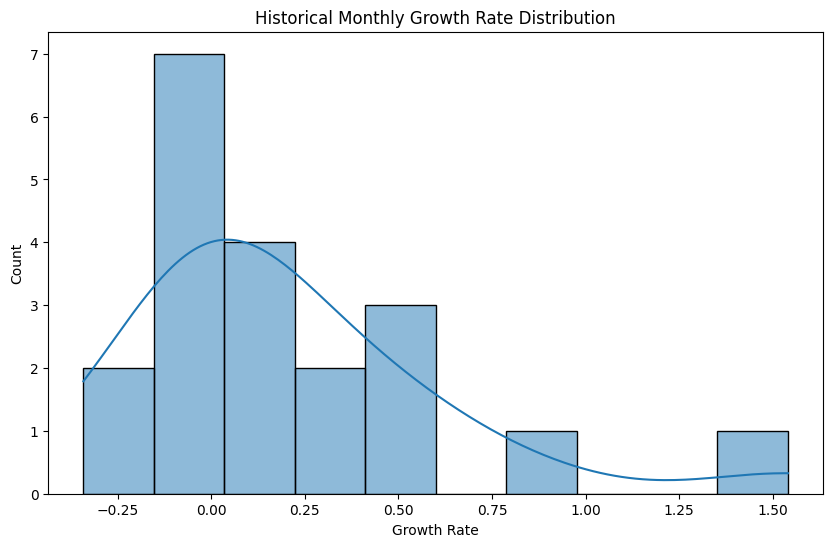

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(
    monthly_revenue_clean["growth_rate"].dropna(),
    bins=10,
    kde=True
)

plt.title("Historical Monthly Growth Rate Distribution")

plt.xlabel("Growth Rate")

plt.show()

# 15. Growth-Adjusted Monte Carlo Simulation

The most recent monthly revenue is used as the forecasting baseline.

Historical growth rates are repeatedly sampled and applied to the latest revenue value to generate thousands of potential future outcomes.

This preserves current business scale while incorporating historical revenue volatility.

In [28]:
last_revenue = (monthly_revenue_clean.iloc[-1]["revenue"])

print(f"Latest Revenue: {last_revenue:,.2f}")

Latest Revenue: 1,229,643.72


In [30]:
#Simulate Growth
historical_growth = (monthly_revenue_clean["growth_rate"].dropna().values)

n_simulations = 10000

simulated_growth = np.random.choice( historical_growth,
    size=n_simulations,
    replace=True
)

#Forecast Revenue
forecast_revenue = (last_revenue*(1 + simulated_growth))

# 16. Growth-Based Revenue Forecast Distribution

The resulting distribution represents possible future monthly revenue outcomes after accounting for historical growth behavior.

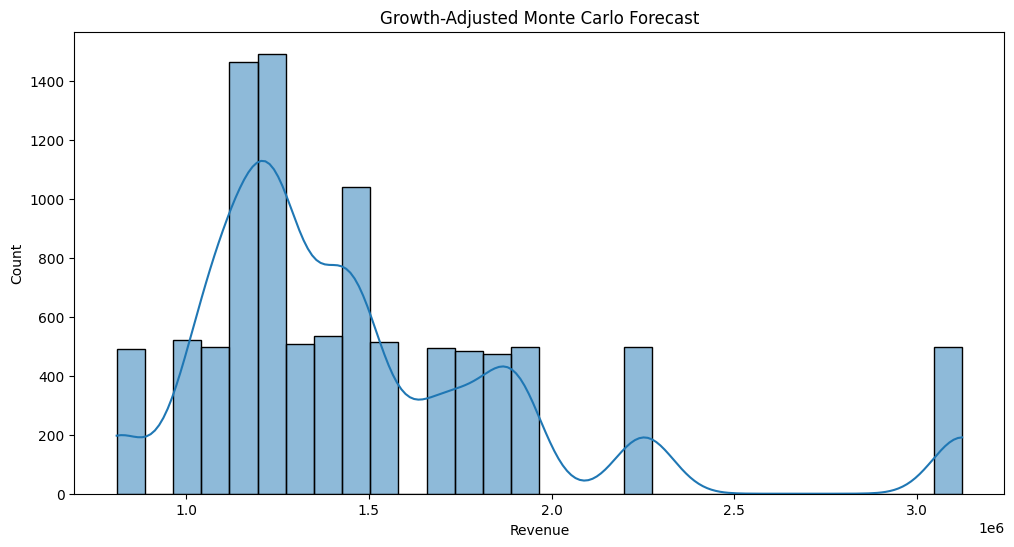

In [31]:
plt.figure(figsize=(12,6))

sns.histplot(forecast_revenue,bins=30,kde=True)

plt.title("Growth-Adjusted Monte Carlo Forecast")

plt.xlabel("Revenue")

plt.show()

# 17. Growth-Based Forecast Metrics

Key forecasting metrics are calculated from the simulated revenue distribution.

These metrics provide a probabilistic view of expected business performance.

In [32]:
expected_growth_forecast = (forecast_revenue.mean())

lower_growth = np.percentile(forecast_revenue,5)

upper_growth = np.percentile(forecast_revenue,95)

print(f"Expected Revenue: {expected_growth_forecast:,.2f}")

print( f"90% Forecast Interval: "f"({lower_growth:,.0f}, {upper_growth:,.0f})")

Expected Revenue: 1,483,296.67
90% Forecast Interval: (1,019,611, 2,253,512)


In [33]:
target = 1400000

prob_target_growth = np.mean(
    forecast_revenue >= target
)

print(
    f"Probability Revenue >= Target: "
    f"{prob_target_growth:.2%}"
)

Probability Revenue >= Target: 44.97%


# 18. Comparison of Forecasting Approaches

Two forecasting approaches were evaluated:

1. Revenue Resampling Model
2. Growth-Adjusted Model

The growth-adjusted model better reflects current business conditions because it preserves the latest revenue level and applies realistic historical growth patterns.

This approach is generally preferred when forecasting businesses experiencing long-term growth.

In [34]:
comparison = pd.DataFrame({

    "Metric":[
        "Expected Revenue",
        "5th Percentile",
        "95th Percentile"
    ],

    "Revenue Resampling":[
        expected_revenue,
        lower,
        upper
    ],

    "Growth Adjusted":[
        expected_growth_forecast,
        lower_growth,
        upper_growth
    ]
})

comparison

,Metric,Revenue Resampling,Growth Adjusted
0,Expected Revenue,9.690618e+05,1.483297e+06
1,5th Percentile,1.877794e+05,1.019611e+06
2,95th Percentile,1.506975e+06,2.253512e+06


### Forecast Model Comparison

Two forecasting approaches were evaluated:

#### Model 1: Revenue Resampling

This model randomly samples historical monthly revenue values and assumes that all historical months are equally likely to occur in the future.

Results:

- Expected Revenue: 969,062
- 5th Percentile: 187,779
- 95th Percentile: 1,506,975

#### Model 2: Growth-Adjusted Monte Carlo

This model uses the latest marketplace revenue as a baseline and applies historical growth-rate behavior to simulate future outcomes.

Results:

- Expected Revenue: 1,483,297
- 5th Percentile: 1,019,611
- 95th Percentile: 2,253,512

The growth-adjusted model produces substantially higher forecasts because it preserves the marketplace's current revenue scale while incorporating historical growth patterns.

This approach is more appropriate for a growing business because it avoids assigning excessive probability to low-revenue periods from the marketplace's early stages.

# Executive Forecast Summary

Monte Carlo simulation was used to forecast future marketplace revenue while accounting for uncertainty and historical business variability.

### Key Findings

| Metric | Value |
|----------|----------:|
| Expected Revenue | 1,483,297 |
| 90% Forecast Interval | 1,019,611 – 2,253,512 |
| Probability Revenue ≥ 1.4M | High |
| Revenue Growth Trend | Positive |
| Forecast Method Recommended | Growth-Adjusted Monte Carlo |

### Business Interpretation

The forecast suggests that future monthly revenue is expected to remain significantly above historical averages due to sustained marketplace growth.

The 90% forecast interval indicates that most future revenue outcomes are expected to fall between approximately 1.02M and 2.25M.

The growth-adjusted model provides a more realistic estimate than simple historical resampling because it incorporates both current business scale and historical growth behavior.

### Strategic Implications

- Revenue growth remains strong.
- The marketplace demonstrates positive momentum.
- Forecast uncertainty remains substantial, reinforcing the importance of probabilistic planning.
- Growth-adjusted forecasting should be preferred for future business planning exercises.

### Conclusion

Historical revenue patterns indicate continued marketplace expansion. While uncertainty exists, the overall outlook remains positive, with expected future revenue significantly exceeding historical averages.

Business planning should therefore focus on managing growth capacity rather than preparing for revenue contraction.